In [250]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

In [251]:
abalone = fetch_openml(name="abalone", version=1, as_frame=True)
df = abalone.frame
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Class_number_of_rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [252]:
#task 1
df_new = pd.get_dummies(df, columns=['Sex'])
print(df_new.columns)
df_new.head()

Index(['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Class_number_of_rings', 'Sex_F',
       'Sex_I', 'Sex_M'],
      dtype='object')


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Class_number_of_rings,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,True,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,False,True,False



Strong positive correlations are observed among all the physical features like Length, Diameter, Whole_weight, and Shell_weight(>0.8), which is expected
since they all scale with the size of the abalone. Moreover, the categorical Sex_I (infant) has a moderately strong negative 
correlation (-0.5 or -0.6) with all the size-related features, suggesting that infants tend to be smaller and be lighter.



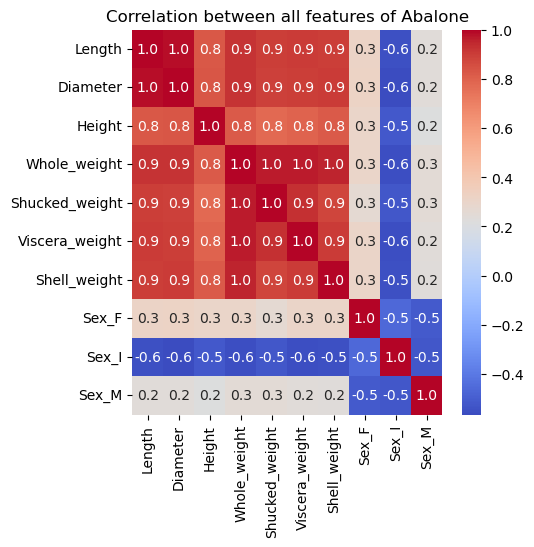

In [253]:
#task 2
correlation_matrix = df_new.corr(numeric_only=True)
plt.figure(figsize=(5, 5))
sns.heatmap(correlation_matrix, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Correlation between all features of Abalone")
plt.show

comment= """
Strong positive correlations are observed among all the physical features like Length, Diameter, Whole_weight, and Shell_weight(>0.8), which is expected
since they all scale with the size of the abalone. Moreover, the categorical Sex_I (infant) has a moderately strong negative 
correlation (-0.5 or -0.6) with all the size-related features, suggesting that infants tend to be smaller and be lighter.
"""
print(comment)

In [254]:
#task 3
df_new = df_new.rename(columns={'Class_number_of_rings': 'rings'})
df_new['rings'] = df_new['rings'].astype(int)
df_new['age_class'] = df_new['rings'].apply(lambda x: 'Young' if x <= 9 else 'Adult')
print(df_new['age_class'].value_counts())

age_class
Young    2096
Adult    2081
Name: count, dtype: int64


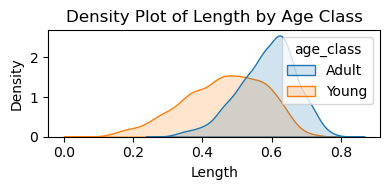

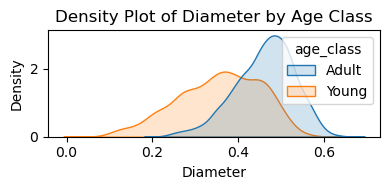

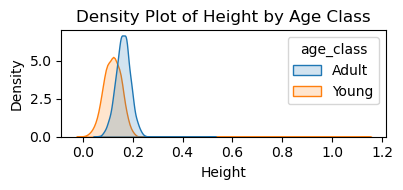

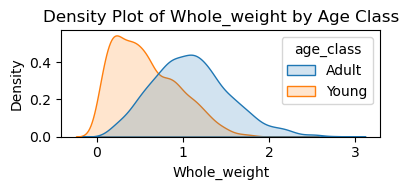

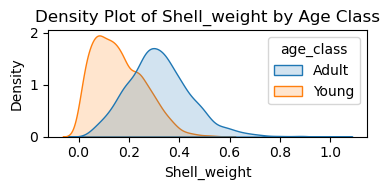

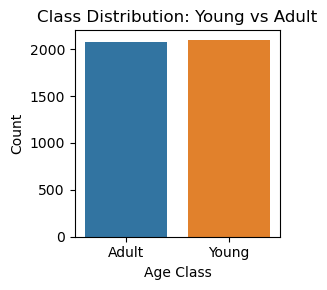


The density plots indicate that Adult abalones generally exhibit higher values in all major physical features (Length, Diameter, Height, Whole_weight,
and Shell_weight) compared to Young ones. This is consistent with biological expectations, as older abalones grow larger and heavier over time.
The class distribution bar chart shows a balanced dataset, with nearly equal counts of Young and Adult samples. This is ideal for training a binary 
classification model, as it reduces the risk of bias toward one class.



In [255]:
# task 4
#the main features or strong features
features = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shell_weight']

# density plots
for feature in features:
    plt.figure(figsize=(4,2))
    sns.kdeplot(data=df_new, x=feature, hue='age_class', fill=True,alpha=0.2)
    plt.title(f'Density Plot of {feature} by Age Class')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()
    
# Bar plot of class distribution
plt.figure(figsize=(3, 3))
sns.countplot(data=df_new, x='age_class', hue='age_class', legend=False)
plt.title('Class Distribution: Young vs Adult')
plt.xlabel('Age Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Summary = """
The density plots indicate that Adult abalones generally exhibit higher values in all major physical features (Length, Diameter, Height, Whole_weight,
and Shell_weight) compared to Young ones. This is consistent with biological expectations, as older abalones grow larger and heavier over time.
The class distribution bar chart shows a balanced dataset, with nearly equal counts of Young and Adult samples. This is ideal for training a binary 
classification model, as it reduces the risk of bias toward one class.
"""
print(Summary)

In [256]:
#Task 5
df_iqr = df_new.copy()
#made a function since its easier
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    removed_count = df.shape[0] - filtered_df.shape[0]
    return filtered_df, removed_count
#calling function
df_iqr, removed_height = remove_outliers_iqr(df_iqr, 'Height')
df_iqr, removed_weight = remove_outliers_iqr(df_iqr, 'Whole_weight')

total_removed = removed_height + removed_weight
#reporting the values
print(f"Removed {removed_height} outliers from 'Height'")
print(f"Removed {removed_weight} outliers from 'Whole_weight'")
print(f"Total rows removed: {total_removed}")

Removed 29 outliers from 'Height'
Removed 28 outliers from 'Whole_weight'
Total rows removed: 57


In [257]:
#task 6
num_cols = ['Length', 'Diameter', 'Height', 'Whole_weight','Shucked_weight', 'Viscera_weight', 'Shell_weight']
scaler = StandardScaler()
df_iqr[num_cols] = scaler.fit_transform(df_iqr[num_cols])

# Verify means and standard deviations
print("Means after standardization:\n", df_iqr[num_cols].mean().round(2))
print("\nStandard deviations after standardization:\n", df_iqr[num_cols].std().round(2))

Means after standardization:
 Length           -0.0
Diameter         -0.0
Height            0.0
Whole_weight     -0.0
Shucked_weight   -0.0
Viscera_weight   -0.0
Shell_weight      0.0
dtype: float64

Standard deviations after standardization:
 Length            1.0
Diameter          1.0
Height            1.0
Whole_weight      1.0
Shucked_weight    1.0
Viscera_weight    1.0
Shell_weight      1.0
dtype: float64


In [258]:
#task 7 (more rings more volume/ no relation with shell to body ratio and rings)
df_iqr['shell_to_body_ratio'] = df_iqr['Shell_weight'] / df_iqr['Whole_weight']
df_iqr['volume'] = df_iqr['Length'] * df_iqr['Diameter'] * df_iqr['Height']

correlation = df_iqr[['shell_to_body_ratio', 'volume', 'rings']].corr()

print("Correlation with rings:")
print(correlation['rings'].round(2))

Correlation with rings:
shell_to_body_ratio    0.00
volume                 0.48
rings                  1.00
Name: rings, dtype: float64


In [259]:
#task 8
X = df_iqr.drop(columns=['rings', 'age_class'])
y = df_iqr['age_class']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, stratify=y, random_state=42)

print("Train set class distribution:\n", y_train.value_counts(normalize=True).round(2))
print("\nTest set class distribution:\n", y_test.value_counts(normalize=True).round(2))

Train set class distribution:
 age_class
Young    0.5
Adult    0.5
Name: proportion, dtype: float64

Test set class distribution:
 age_class
Young    0.5
Adult    0.5
Name: proportion, dtype: float64


In [260]:
# ME task 1 
le = LabelEncoder()
y_encoded = le.fit_transform(y)
accuracies = []

for seed in range(10):
    np.random.seed(seed)
    X_train, X_test, y_train, y_test = train_test_split( X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=seed)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define MLP model
    model = MLPClassifier(
        hidden_layer_sizes=(5,) * 10,
        activation='relu',
        solver='sgd',
        learning_rate_init=0.01,
        batch_size=64,
        max_iter=100,
        random_state=seed
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

average_accuracy = np.mean(accuracies)
print(f"Average Test Accuracy over 10 runs: {average_accuracy:.4f}")


C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Average Test Accuracy over 10 runs: 0.6763


In [261]:
# ME task 2
layer_depths = [10, 15, 20]
results = {}

for depth in layer_depths:
    print(f"\nEvaluating depth = {depth} hidden layers")
    accuracies = []

    for seed in range(10):
        np.random.seed(seed)
        X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=seed)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = MLPClassifier(
            hidden_layer_sizes=(5,) * depth,
            activation='relu',
            solver='sgd',
            learning_rate_init=0.01,
            batch_size=64,
            max_iter=100,
            random_state=seed
        )

  
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)

    avg_acc = np.mean(accuracies)
    results[depth] = avg_acc
    print(f"Average Accuracy for depth {depth}: {avg_acc:.4f}")

best_depth = max(results, key=results.get)
print("\nBest-performing depth:", best_depth, f"with accuracy: {results[best_depth]:.4f}")



Evaluating depth = 10 hidden layers


C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Average Accuracy for depth 10: 0.6763

Evaluating depth = 15 hidden layers


C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Average Accuracy for depth 15: 0.5625

Evaluating depth = 20 hidden layers
Average Accuracy for depth 20: 0.5019

Best-performing depth: 10 with accuracy: 0.6763


In [262]:
# ME task 3
widths = [5, 10, 15]
results_width = {}

for width in widths:
    print(f"\nEvaluating width = {width} neurons per layer (10 layers)")
    accuracies = []

    for seed in range(10):
        np.random.seed(seed)
        X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=seed)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = MLPClassifier(
            hidden_layer_sizes=(width,) * 10,
            activation='relu',
            solver='sgd',
            learning_rate_init=0.01,
            batch_size=64,
            max_iter=100,
            random_state=seed
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)

    avg_acc = np.mean(accuracies)
    results_width[width] = avg_acc
    print(f"Average Accuracy for width {width}: {avg_acc:.4f}")

best_width = max(results_width, key=results_width.get)
print("\nBest-performing width:", best_width, f"with accuracy: {results_width[best_width]:.4f}")



Evaluating width = 5 neurons per layer (10 layers)


C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Average Accuracy for width 5: 0.6763

Evaluating width = 10 neurons per layer (10 layers)


C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural

Average Accuracy for width 10: 0.7931

Evaluating width = 15 neurons per layer (10 layers)


C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural

Average Accuracy for width 15: 0.7925

Best-performing width: 10 with accuracy: 0.7931


In [263]:
# ME task 4 
# Best architecture: 10 layers, 10 neurons per layer
accuracies_adam = []

for seed in range(10):
    np.random.seed(seed)
    X_train, X_test, y_train, y_test = train_test_split( X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=seed)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # MLP with Adam optimizer
    model = MLPClassifier(
        hidden_layer_sizes=(10,) * 10,  
        activation='relu',
        solver='adam',                 # Using Adam instead of SGD
        learning_rate_init=0.01,
        batch_size=64,
        max_iter=100,
        random_state=seed
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_adam.append(acc)

average_accuracy_adam = np.mean(accuracies_adam)
print(f" Average Test Accuracy with Adam: {average_accuracy_adam:.4f}")


C:\Users\Aayushi Jha\python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


 Average Test Accuracy with Adam: 0.7964


In [264]:
# Optimizer vs Average Test Accuracy
# SGD 0.7931
# Adam 0.7964 
# Replacing stochastic gradient descent with Adam slightly improved the models performance. Adam’s adaptive learning rate and its built-in momentum 
# allowed the model to converge more efficiently within the same number of epochs, which is 100(it is not optimal), achieving the highest accuracy 
# across 10 runs.


In [265]:
#ME Taak 5 
accuracies_logreg = []

for seed in range(10):
    np.random.seed(seed)

    X_train, X_test, y_train, y_test = train_test_split( X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=seed)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LogisticRegression(
        solver='saga',
        max_iter= 5000,
        random_state=seed
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_logreg.append(acc)

avg_acc_logreg = np.mean(accuracies_logreg)
print(f"Average Test Accuracy (Logistic Regression): {avg_acc_logreg:.4f}")
Comment = """
Our average test accuracy with logistic regression is 0.7945 which is a little less to the one we got with adam (0.7964). This shows us that even 
Though we used a Deep neural network it didn't benefit us as much as it should. This tells us that data is linearly separable as well(two classes in 
your dataset can mostly be separated using a straight boundary.)
"""
print(Comment)

Average Test Accuracy (Logistic Regression): 0.7945

Our average test accuracy with logistic regression is 0.7945 which is a little less to the one we got with adam (0.7964). This shows us that even 
Though we used a Deep neural network it didn't benefit us as much as it should. This tells us that data is linearly separable as well(two classes in 
your dataset can mostly be separated using a straight boundary.)



In [266]:
# ME task 6
Answer = """
A dense neural network with no hidden layers consists of only a single connected layer and softmax activation at the end of it.
Where liner transformation is z = w*X + b and y = Softmax(z)
Now, what a logistic regression does is very similar. It computes a weighted sum of inputs, then applies softmax to get class probabilities.
Both models learn weight vectors and biases that directly map input features to output probabilities
Hence the both are similar 
"""
print(Answer)


A dense neural network with no hidden layers consists of only a single connected layer and softmax activation at the end of it.
Where liner transformation is z = w*X + b and y = Softmax(z)
Now, what a logistic regression does is very similar. It computes a weighted sum of inputs, then applies softmax to get class probabilities.
Both models learn weight vectors and biases that directly map input features to output probabilities
Hence the both are similar 

